<a href="https://www.kaggle.com/code/subhadiphensh/fashion-mnist-fnn-model?scriptVersionId=291397342" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install "protobuf<4" --no-deps -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.5 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import platform
import math

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.datasets import fashion_mnist
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

2026-01-12 06:50:31.459938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768200631.809854      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768200631.910077      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print(f"Python Version : {platform.python_version()}")
print(f'Tensorflow Version : {tf.__version__}')
print(f"Keras Version : {tf.keras.__version__}")

Python Version : 3.11.13
Tensorflow Version : 2.18.0
Keras Version : 3.8.0


In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train : (60000, 28, 28)
y_train : (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


In [6]:
(_, IMAGE_WIDTH, IMAGE_HEIGHT) = X_train.shape
IMAGE_CHANNELS = 1

print(f"IMAGE_WIDTH : {IMAGE_WIDTH}")
print(f"IMAGE_HEIGHT : {IMAGE_HEIGHT}")
print(f"IMAGE_CHANNELS : {IMAGE_CHANNELS}")

IMAGE_WIDTH : 28
IMAGE_HEIGHT : 28
IMAGE_CHANNELS : 1


In [7]:
pd.set_option("display.max_columns", None)

In [8]:
pd.DataFrame(X_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,13,73,0,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,3,0,36,136,127,62,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,0,0,6,0,102,204,176,134,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,155,236,207,178,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,0,1,0,69,207,223,218,216,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,1,1,0,200,232,232,233,229,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,183,225,216,223,228,235,227,224,222,224,221,223,245,173,0


In [9]:
pd.DataFrame(X_test[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,0,0,7,0,37,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,27,84,11,0,0,0,0,0,0,119,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,88,143,110,0,0,0,0,22,93,106,0,0


In [10]:
plt.style.use('dark_background')

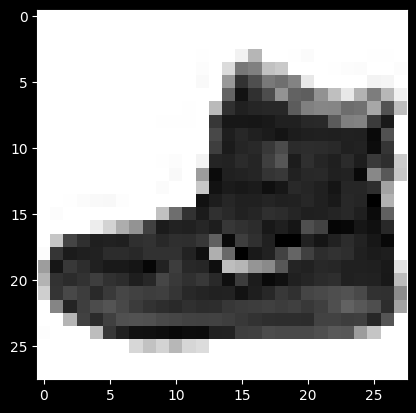

In [11]:
plt.imshow(X_train[0], cmap = plt.cm.binary)
plt.show()

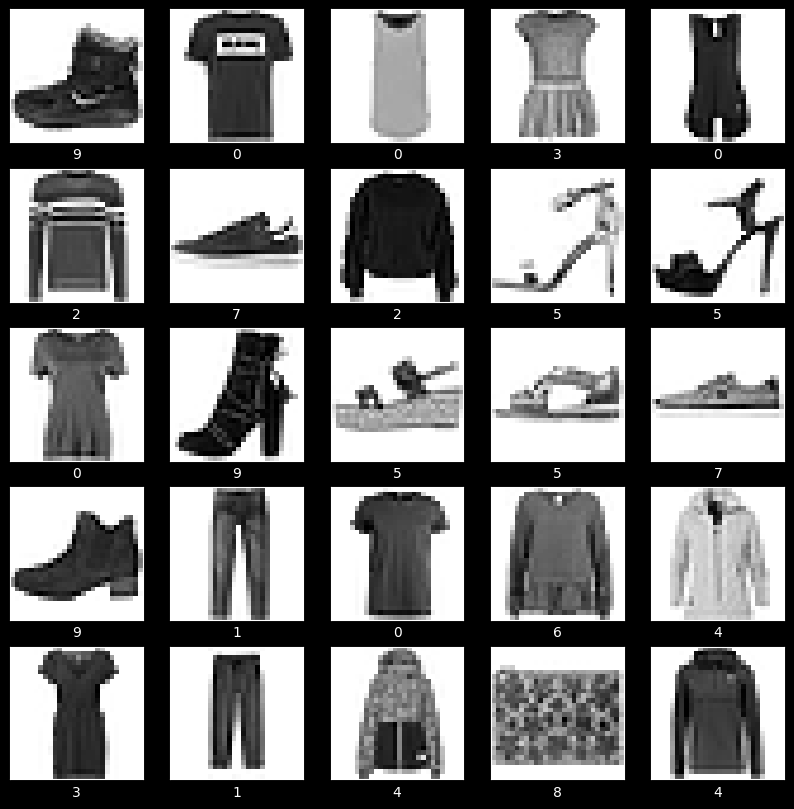

In [12]:
numbers_to_display = 25

num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize = (10,10))

for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap = plt.cm.binary)
    plt.xlabel(y_train[i])

plt.show()

In [13]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

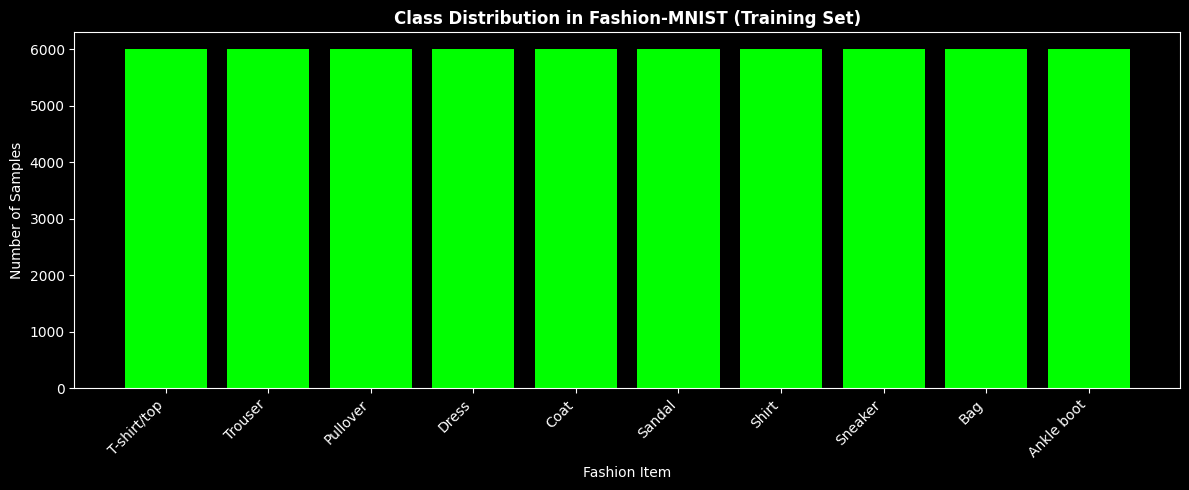

In [14]:
unique, counts = np.unique(y_train, return_counts = True)

plt.figure(figsize = (12, 5))
plt.bar(class_names, counts, color = 'Lime')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("Fashion Item")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Fashion-MNIST (Training Set)", fontweight = "semibold")
plt.tight_layout()
plt.show()

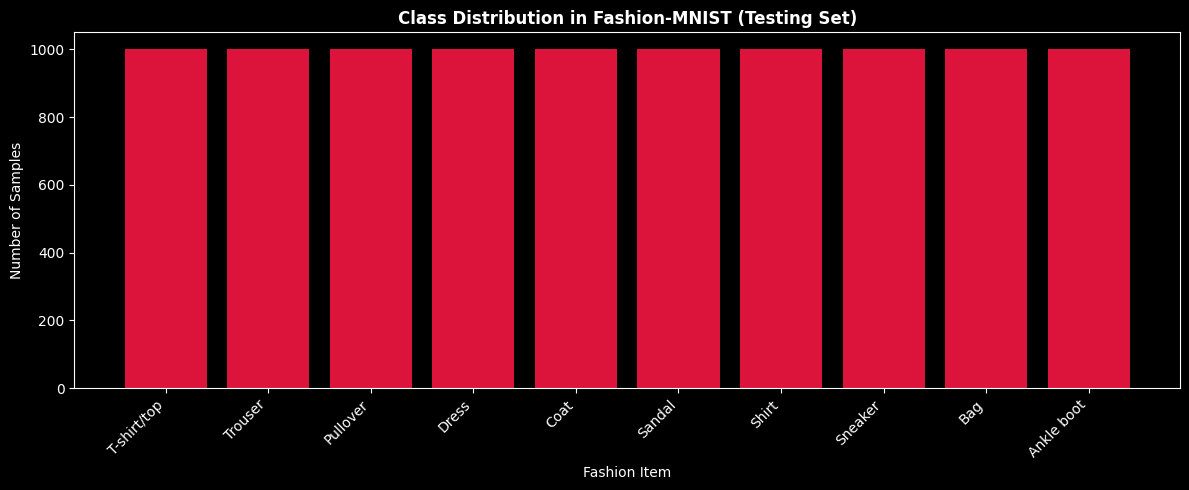

In [15]:
unique, counts = np.unique(y_test, return_counts = True)

plt.figure(figsize = (12, 5))
plt.bar(class_names, counts, color = 'Crimson')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("Fashion Item")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Fashion-MNIST (Testing Set)", fontweight = "semibold")
plt.tight_layout()
plt.show()

In [16]:
X_train_with_channels = X_train.reshape(
    X_train.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

X_test_with_channels = X_test.reshape(
    X_test.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

In [17]:
print(f"X_train_with_channels : {X_train_with_channels.shape}")
print(f"X_Test_with_channels : {X_test_with_channels.shape}")

X_train_with_channels : (60000, 28, 28, 1)
X_Test_with_channels : (10000, 28, 28, 1)


In [18]:
X_train_normalized = X_train_with_channels / 255.
X_test_normalized = X_test_with_channels / 255.

In [19]:
X_train_normalized[0][18]

array([[0.01176471],
       [0.79215686],
       [0.89411765],
       [0.87843137],
       [0.86666667],
       [0.82745098],
       [0.82745098],
       [0.83921569],
       [0.80392157],
       [0.80392157],
       [0.80392157],
       [0.8627451 ],
       [0.94117647],
       [0.31372549],
       [0.58823529],
       [1.        ],
       [0.89803922],
       [0.86666667],
       [0.7372549 ],
       [0.60392157],
       [0.74901961],
       [0.82352941],
       [0.8       ],
       [0.81960784],
       [0.87058824],
       [0.89411765],
       [0.88235294],
       [0.        ]])

In [20]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [21]:
print(y_train)
print("-" * 50)
print(y_test)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
--------------------------------------------------
[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [22]:
def create_model(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS):
    FNN_model = Sequential(
        [
            Flatten(input_shape = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
            Dense(1000, activation = "relu"),
            Dropout(0.3),
            Dense(500, activation = 'relu'),
            Dropout(0.3),
            Dense(10, activation = "softmax")
        ]
    )

    FNN_model.compile(
        optimizer = 'SGD',
        loss = "categorical_crossentropy",
        metrics = ['accuracy']
    )

    return FNN_model.summary(), FNN_model

In [23]:
_, model = create_model(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)

2026-01-12 06:50:55.183619: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,510 (4.92 MB)

 Trainable params: 1,290,510 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

In [25]:
history_FNN = model.fit(
    X_train_normalized,
    y_train,
    validation_split = 0.2,
    epochs = 30,
    batch_size = 32,
    callbacks = [early_stop]
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6425 - loss: 1.0764 - val_accuracy: 0.8212 - val_loss: 0.5277
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8045 - loss: 0.5576 - val_accuracy: 0.8382 - val_loss: 0.4623
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8259 - loss: 0.4947 - val_accuracy: 0.8460 - val_loss: 0.4367
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8409 - loss: 0.4561 - val_accuracy: 0.8554 - val_loss: 0.4151
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8489 - loss: 0.4289 - val_accuracy: 0.8610 - val_loss: 0.3941
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8573 - loss: 0.4036 - val_accuracy: 0.8625 - val_loss: 0.3871
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8606 - loss: 0.3902 - val_accuracy: 0.8671 - val_loss: 0.3708
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8655 - loss: 0

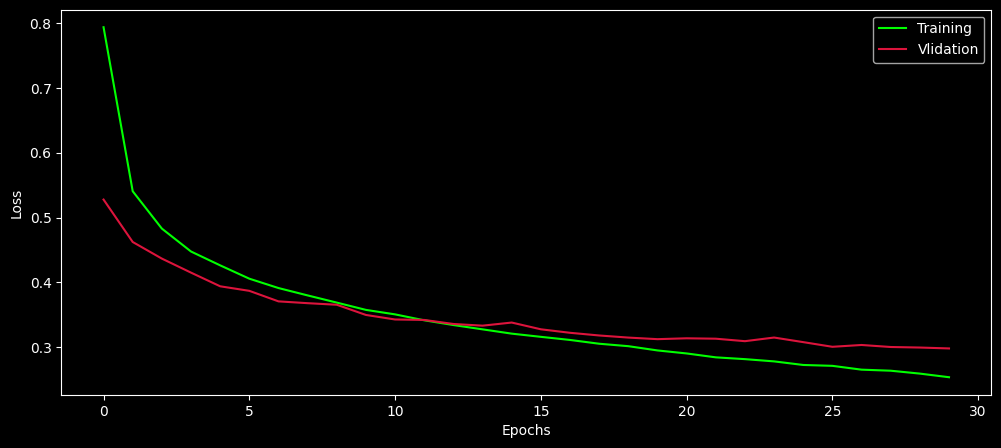

In [26]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['loss'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_loss'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

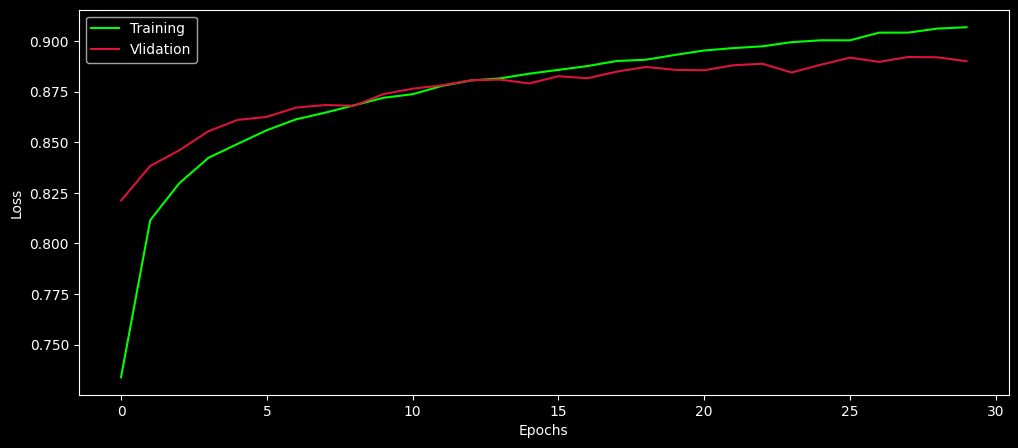

In [27]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['accuracy'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_accuracy'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [28]:
model.save("FNN_MNIST_FNN_model.keras")

In [30]:
load_model = tf.keras.models.load_model("/kaggle/working/FNN_MNIST_FNN_model.keras")

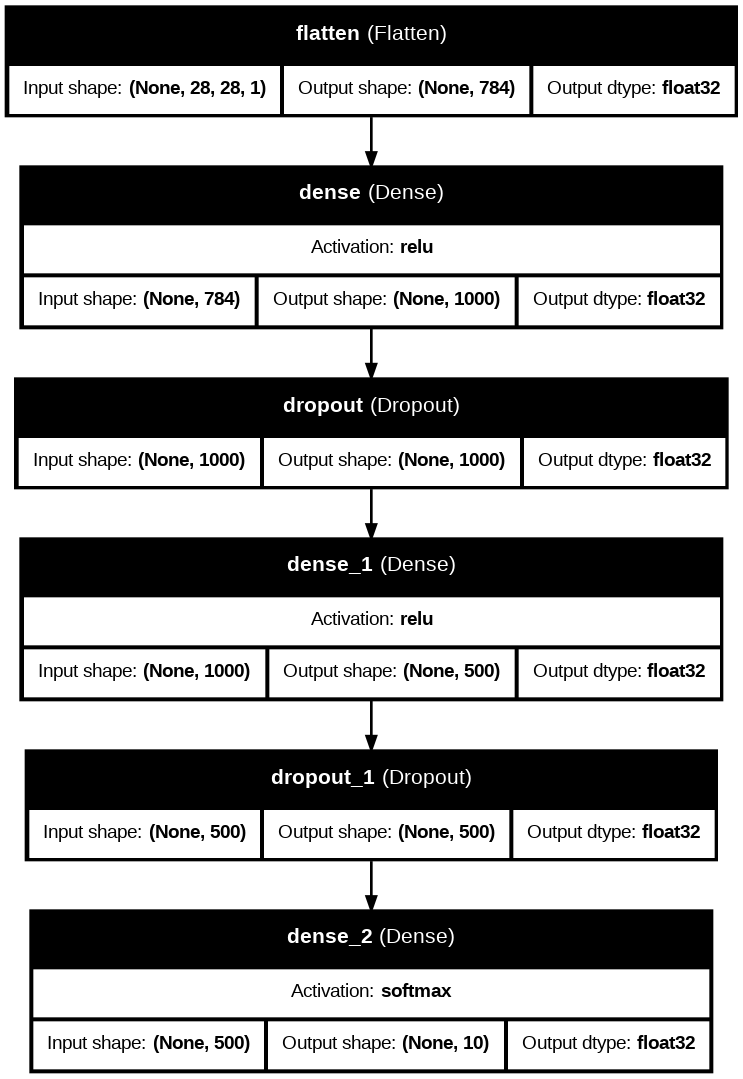

In [31]:
keras.utils.plot_model(
    model,
    to_file = "model.png",
    show_shapes = True,
    show_dtype = True,
    show_layer_names = True,
    rankdir="TB",
    expand_nested = True,
    dpi = 96,
    show_layer_activations = True,
    show_trainable=False,
)

In [32]:
train_loss, train_accuracy = load_model.evaluate(X_train_normalized, y_train)

print(f"Training Loss : {train_loss}")
print(f"Training Accuracy : {train_accuracy}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9197 - loss: 0.2209
Training Loss : 0.23593255877494812
Training Accuracy : 0.9146333336830139


In [33]:
validation_loss, validation_accuracy = load_model.evaluate(X_test_normalized, y_test)

print(f"Training Loss : {validation_loss}")
print(f"Training Accuracy : {validation_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8803 - loss: 0.3240
Training Loss : 0.32285013794898987
Training Accuracy : 0.8827000260353088


In [34]:
predictions_one_hot = load_model.predict([X_test_normalized])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [35]:
print(f"predictions_one_hot : {predictions_one_hot.shape}")

predictions_one_hot : (10000, 10)


In [36]:
pd.DataFrame(predictions_one_hot)

,0,1,2,3,4,5,6,7,8,9
0,6.101519e-06,8.503326e-06,4.549858e-06,6.927140e-06,4.219629e-06,1.882682e-03,1.120926e-05,1.215739e-02,6.281729e-05,9.858555e-01
1,1.597701e-05,6.131061e-08,9.993348e-01,5.074013e-08,3.467792e-04,1.690728e-09,3.023719e-04,4.494191e-10,4.665039e-08,5.180384e-10
2,1.794152e-07,9.999996e-01,1.429785e-08,7.300530e-08,4.368226e-08,9.512775e-11,6.595773e-10,1.234527e-10,1.580558e-09,9.786143e-11
3,5.226781e-07,9.999915e-01,1.233099e-07,7.468209e-06,2.443035e-07,1.441152e-09,3.510489e-08,9.578265e-10,1.209027e-09,6.935687e-09
4,7.860367e-02,7.214354e-05,1.211166e-02,2.491949e-03,6.321713e-03,2.571696e-04,8.993878e-01,3.793777e-05,6.193903e-04,9.638345e-05
...,...,...,...,...,...,...,...,...,...,...
9995,7.672837e-09,1.138705e-08,1.527293e-09,1.065164e-09,1.981693e-09,2.145593e-06,3.591621e-09,1.028543e-04,7.133818e-09,9.998949e-01
9996,1.102069e-04,9.995108e-01,5.548947e-05,2.926652e-04,1.908550e-05,1.262566e-07,1.018785e-05,2.321603e-07,3.239417e-07,9.142952e-07
9997,1.027102e-03,1.063601e-07,1.918979e-04,1.025473e-04,1.564259e-04,2.256317e-06,9.658723e-05,1.274284e-06,9.984217e-01,5.436252e-08
9998,2.154814e-06,9.998869e-01,8.575107e-07,1.059008e-04,1.267041e-06,3.844409e-08,8.580629e-07,1.748552e-07,3.353040e-07,1.512002e-06


In [37]:
predictions_one_hot.sum(axis = 1)[0]

0.9999999

In [38]:
for i in range(10):
    print(f"{i} row sum is : {predictions_one_hot.sum(axis = 1)[0]}")

0 row sum is : 0.9999998807907104
1 row sum is : 0.9999998807907104
2 row sum is : 0.9999998807907104
3 row sum is : 0.9999998807907104
4 row sum is : 0.9999998807907104
5 row sum is : 0.9999998807907104
6 row sum is : 0.9999998807907104
7 row sum is : 0.9999998807907104
8 row sum is : 0.9999998807907104
9 row sum is : 0.9999998807907104


In [39]:
predictions = np.argmax(predictions_one_hot, axis = 1)
pd.DataFrame(predictions)

,0
0,9
1,2
2,1
3,1
4,6
...,...
9995,9
9996,1
9997,8
9998,1


In [40]:
for i in range(10):
    print(class_names[predictions[i]], end = ",")

Ankle boot,Pullover,Trouser,Trouser,Shirt,Trouser,Coat,Shirt,Sandal,Sneaker,

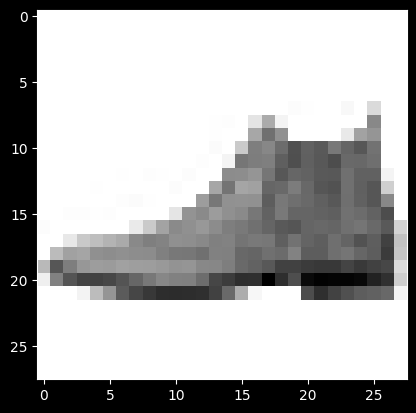

In [41]:
plt.imshow(X_test_normalized[0].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)), cmap = plt.cm.binary)
plt.show()

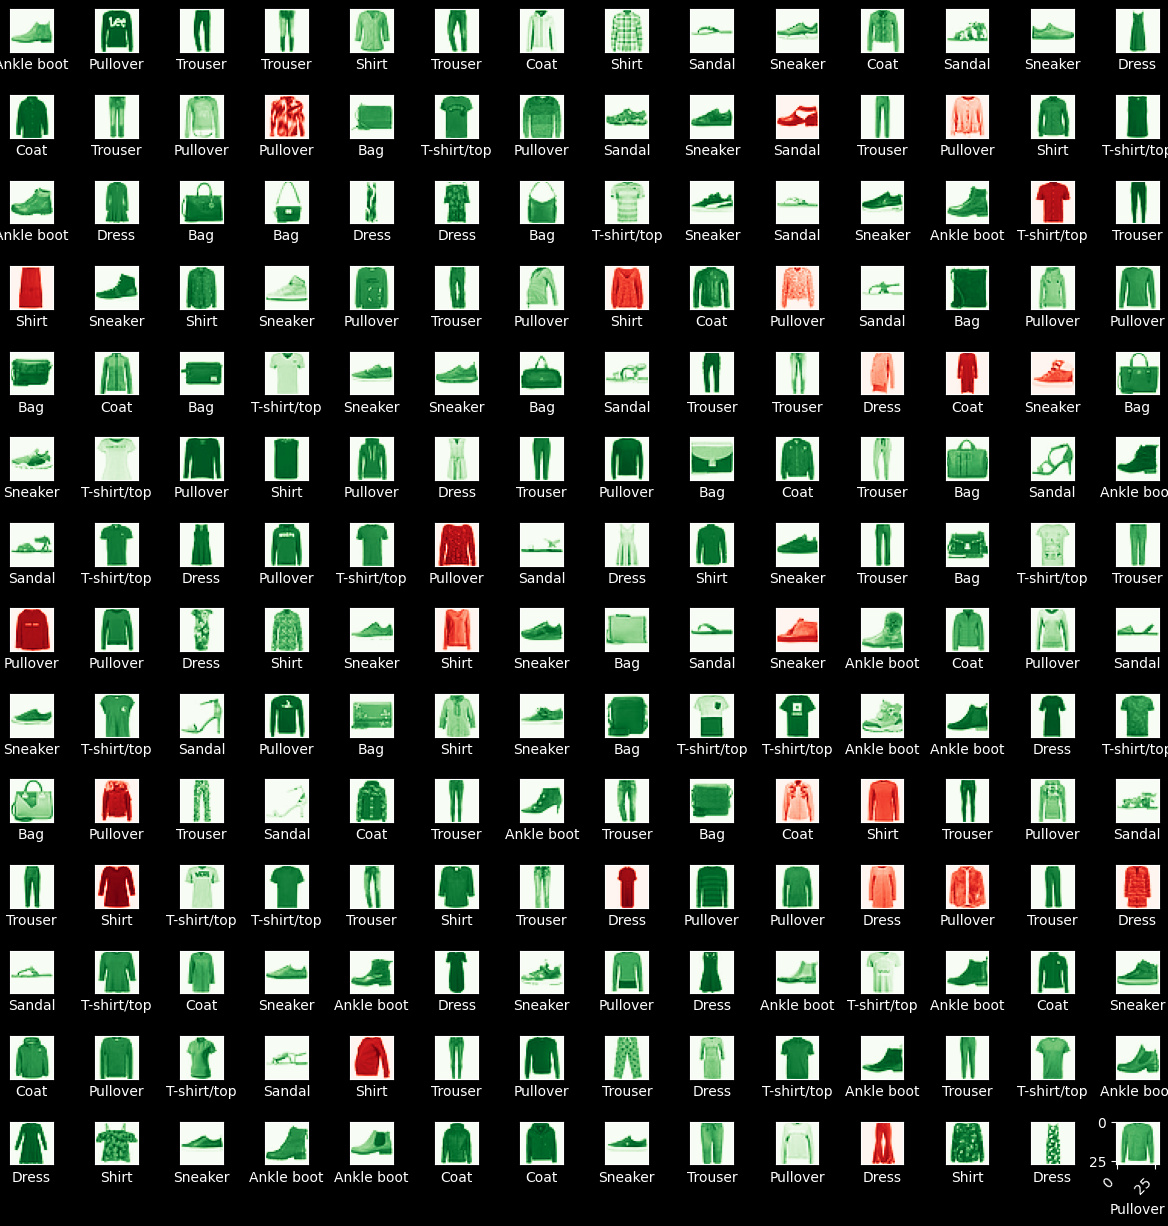

In [42]:
items_to_display = 196

num_cells = math.ceil(math.sqrt(items_to_display))
plt.figure(figsize = (15, 15))

for plot_index in range(items_to_display):
    predicted_label = predictions[plot_index]
    true_label = np.argmax(y_test[plot_index])

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    color_map = "Greens" if predicted_label == true_label else "Reds"

    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(
        X_test_normalized[plot_index].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)),
        cmap = color_map
    )
    plt.xlabel(class_names[predicted_label])
    plt.xticks(rotation = 45, ha = 'right')

plt.subplots_adjust(hspace = 1, wspace = 0.5)
plt.show()

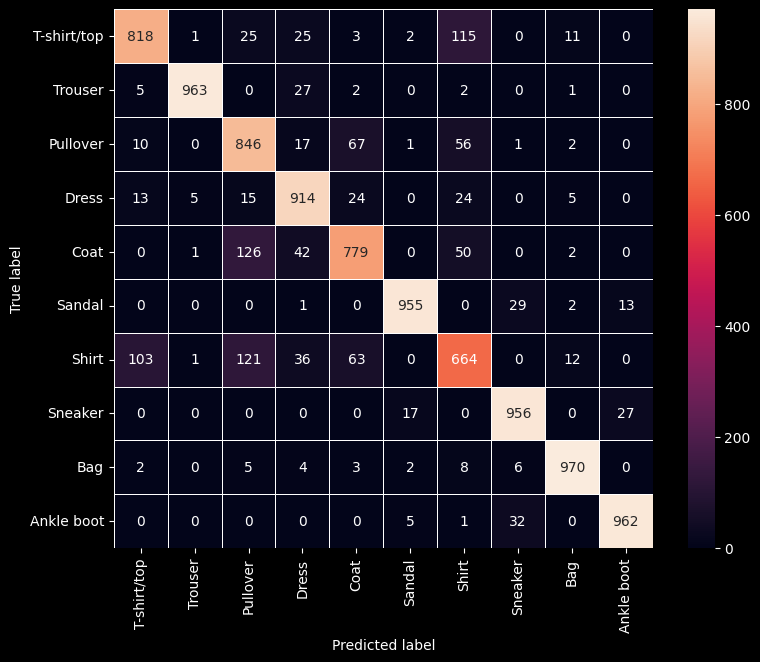

In [43]:
true_labels = np.argmax(y_test, axis = 1)

confusion_matrix = tf.math.confusion_matrix(
    true_labels,
    predictions
)

f, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    confusion_matrix,
    annot = True,
    linewidths = 0.5,
    fmt = "d",
    square = True,
    ax = ax,
    xticklabels = class_names,
    yticklabels = class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()